# Imports + setup

In [6]:
import pandas as pd
import numpy as np
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "/kaggle/input/competitions/shopee-product-matching"

train = pd.read_csv(
    os.path.join(DATA_DIR, "train.csv")
)

print("Shape:", train.shape)
print(train.head())
print(train.columns.tolist())

Shape: (34250, 5)
         posting_id                                 image       image_phash  \
0   train_129225211  0000a68812bc7e98c42888dfb1c07da0.jpg  94974f937d4c2433   
1  train_3386243561  00039780dfc94d01db8676fe789ecd05.jpg  af3f9460c2838f0f   
2  train_2288590299  000a190fdd715a2a36faed16e2c65df7.jpg  b94cb00ed3e50f78   
3  train_2406599165  00117e4fc239b1b641ff08340b429633.jpg  8514fc58eafea283   
4  train_3369186413  00136d1cf4edede0203f32f05f660588.jpg  a6f319f924ad708c   

                                               title  label_group  
0                          Paper Bag Victoria Secret    249114794  
1  Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...   2937985045  
2        Maling TTS Canned Pork Luncheon Meat 397 gr   2395904891  
3  Daster Batik Lengan pendek - Motif Acak / Camp...   4093212188  
4                  Nescafe \xc3\x89clair Latte 220ml   3648931069  
['posting_id', 'image', 'image_phash', 'title', 'label_group']


In [7]:
groups = train["label_group"].unique()

train_groups, temp_groups = train_test_split(
    groups,
    test_size=0.30,
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    random_state=42
)

train_data = train[
    train["label_group"].isin(train_groups)
].copy()

val_data = train[
    train["label_group"].isin(val_groups)
].copy()

test_data = train[
    train["label_group"].isin(test_groups)
].copy()

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (23629, 5)
Validation: (5189, 5)
Test: (5432, 5)


# Create validation/test pairs

In [8]:
from collections import defaultdict

def create_pairs(data, n_pairs, seed=42):

    rng = np.random.default_rng(seed)

    groups = defaultdict(list)

    for idx in data.index:
        groups[train.loc[idx, "label_group"]].append(idx)

    group_list = list(groups.keys())

    positive_pairs = set()
    negative_pairs = set()

    target_positive = n_pairs // 2
    target_negative = n_pairs - target_positive

    # Positive pairs: same product group
    while len(positive_pairs) < target_positive:

        group = rng.choice(group_list)
        members = groups[group]

        if len(members) < 2:
            continue

        a, b = rng.choice(members, size=2, replace=False)

        positive_pairs.add(tuple(sorted((int(a), int(b)))))

    # Negative pairs: different product groups
    while len(negative_pairs) < target_negative:

        g1, g2 = rng.choice(group_list, size=2, replace=False)

        a = rng.choice(groups[g1])
        b = rng.choice(groups[g2])

        negative_pairs.add(tuple(sorted((int(a), int(b)))))

    pairs = []

    for a, b in positive_pairs:
        pairs.append([a, b, 1])

    for a, b in negative_pairs:
        pairs.append([a, b, 0])

    pairs = pd.DataFrame(
        pairs,
        columns=["idx1", "idx2", "label"]
    )

    return pairs.sample(
        frac=1,
        random_state=seed
    ).reset_index(drop=True)

# Generate Pairs

In [9]:
val_pairs = create_pairs(
    val_data,
    3304,
    seed=42
)

test_pairs = create_pairs(
    test_data,
    3306,
    seed=43
)

print("Validation pairs:", val_pairs.shape)
print("Test pairs:", test_pairs.shape)

print("\nValidation:")
print(val_pairs["label"].value_counts())

print("\nTest:")
print(test_pairs["label"].value_counts())

Validation pairs: (3304, 3)
Test pairs: (3306, 3)

Validation:
label
1    1652
0    1652
Name: count, dtype: int64

Test:
label
0    1653
1    1653
Name: count, dtype: int64


# Character TF-IDF (Best Model From Task B)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2
)

vectorizer.fit(train_data["title"])

text_embeddings = vectorizer.transform(
    train["title"]
)

print("Text embedding shape:", text_embeddings.shape)

Text embedding shape: (34250, 171591)


# Generating Text - Pair Similarity Scores

In [11]:
def text_pair_scores(pairs, embeddings):

    idx1 = pairs["idx1"].values
    idx2 = pairs["idx2"].values

    scores = np.asarray(
        embeddings[idx1].multiply(
            embeddings[idx2]
        ).sum(axis=1)
    ).ravel()

    return scores

In [12]:
val_text = text_pair_scores(
    val_pairs,
    text_embeddings
)

test_text = text_pair_scores(
    test_pairs,
    text_embeddings
)

print("Validation text scores:", val_text.shape)
print("Test text scores:", test_text.shape)

Validation text scores: (3304,)
Test text scores: (3306,)


# ResNET50 (Best Model From Task C)

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

import torchvision
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

weights = ResNet50_Weights.DEFAULT

resnet = resnet50(weights=weights)

# Remove classifier
resnet.fc = nn.Identity()

resnet = resnet.to(device)
resnet.eval()

transform = weights.transforms()

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s] 


# Image dataset

In [14]:
IMAGE_DIR = "/kaggle/input/competitions/shopee-product-matching/train_images"

class ImageDataset(Dataset):

    def __init__(self, image_names):
        self.image_names = image_names

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]

        path = os.path.join(
            IMAGE_DIR,
            image_name
        )

        image = Image.open(path).convert("RGB")
        image = transform(image)

        return image, image_name

# Generating ResNet50 embeddings

In [15]:
unique_images = train["image"].unique()

print("Unique images:", len(unique_images))

Unique images: 32412


In [16]:
image_dataset = ImageDataset(unique_images)

image_loader = DataLoader(
    image_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [18]:
image_embeddings_dict = {}

with torch.no_grad():

    for images, names in tqdm(image_loader):

        images = images.to(device)

        embeddings = resnet(images)

        embeddings = torch.nn.functional.normalize(
            embeddings,
            p=2,
            dim=1
        )

        embeddings = embeddings.cpu().numpy()

        for name, embedding in zip(names, embeddings):
            image_embeddings_dict[name] = embedding

print(
    "Images embedded:",
    len(image_embeddings_dict)
)

  0%|          | 0/507 [00:00<?, ?it/s]

Images embedded: 32412


In [19]:
image_embeddings = np.vstack([
    image_embeddings_dict[name]
    for name in train["image"]
])

print("Shape:", image_embeddings.shape)

Shape: (34250, 2048)


In [20]:
np.save(
    "/kaggle/working/resnet50_finale_embeddings.npy",
    image_embeddings
)

# Image pair similarity

In [21]:
def image_pair_scores(pairs, embeddings):

    idx1 = pairs["idx1"].values
    idx2 = pairs["idx2"].values

    return np.sum(
        embeddings[idx1] * embeddings[idx2],
        axis=1
    )

In [22]:
val_image = image_pair_scores(
    val_pairs,
    image_embeddings
)

test_image = image_pair_scores(
    test_pairs,
    image_embeddings
)

print(val_image.shape)
print(test_image.shape)

(3304,)
(3306,)


# pHash similarity

In [24]:
def phash_pair_scores(pairs):

    idx1 = pairs["idx1"].values
    idx2 = pairs["idx2"].values

    hash1 = train.loc[idx1, "image_phash"].values
    hash2 = train.loc[idx2, "image_phash"].values

    return (hash1 == hash2).astype(float)

In [25]:
val_phash = phash_pair_scores(val_pairs)
test_phash = phash_pair_scores(test_pairs)

print("Validation pHash matches:", val_phash.sum())
print("Test pHash matches:", test_phash.sum())

Validation pHash matches: 229.0
Test pHash matches: 240.0


In [26]:
def find_best_threshold(scores, labels):

    best_threshold = 0
    best_f1 = 0

    for threshold in np.arange(0.05, 0.96, 0.01):

        predictions = (scores >= threshold)

        tp = np.sum((predictions == 1) & (labels == 1))
        fp = np.sum((predictions == 1) & (labels == 0))
        fn = np.sum((predictions == 0) & (labels == 1))

        if tp + fp == 0 or tp + fn == 0:
            continue

        precision = tp / (tp + fp)
        recall = tp / (tp + fn)

        if precision + recall == 0:
            f1 = 0
        else:
            f1 = 2 * precision * recall / (precision + recall)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    return best_threshold, best_f1

# Experiment 0 — Individual modality baselines (How good is each source by itself)

# a) TEXT ONLY

In [27]:
val_y = val_pairs["label"].values
test_y = test_pairs["label"].values

text_threshold, text_val_f1 = find_best_threshold(
    val_text,
    val_y
)

text_test_pred = (
    test_text >= text_threshold
).astype(int)

text_test_f1 = f1_score(
    test_y,
    text_test_pred
)

print("TEXT ONLY")
print("Best threshold:", text_threshold)
print("Validation F1:", text_val_f1)
print("Test Precision:", precision_score(test_y, text_test_pred))
print("Test Recall:", recall_score(test_y, text_test_pred))
print("Test F1:", text_test_f1)

TEXT ONLY
Best threshold: 0.07
Validation F1: 0.9819957277998168
Test Precision: 0.9877074370006146
Test Recall: 0.9721718088324259
Test F1: 0.9798780487804878


# Image-only

In [28]:
image_threshold, image_val_f1 = find_best_threshold(
    val_image,
    val_y
)

image_test_pred = (
    test_image >= image_threshold
).astype(int)

image_test_f1 = f1_score(
    test_y,
    image_test_pred
)

print("IMAGE ONLY")
print("Best threshold:", image_threshold)
print("Validation F1:", image_val_f1)
print("Test Precision:", precision_score(test_y, image_test_pred))
print("Test Recall:", recall_score(test_y, image_test_pred))
print("Test F1:", image_test_f1)

IMAGE ONLY
Best threshold: 0.4100000000000001
Validation F1: 0.929458068422646
Test Precision: 0.9295689131754705
Test Recall: 0.926194797338173
Test F1: 0.9278787878787879


# Experiment 1 — 50/50 Multimodal Baseline

In [29]:
val_score_50 = (
    0.5 * val_text +
    0.5 * val_image
)

fusion_threshold, fusion_val_f1 = find_best_threshold(
    val_score_50,
    val_y
)

test_score_50 = (
    0.5 * test_text +
    0.5 * test_image
)

test_pred_50 = (
    test_score_50 >= fusion_threshold
).astype(int)

print("TEXT + IMAGE (50/50)")
print("Best threshold:", fusion_threshold)
print("Validation F1:", fusion_val_f1)
print("Test Precision:", precision_score(test_y, test_pred_50))
print("Test Recall:", recall_score(test_y, test_pred_50))
print("Test F1:", f1_score(test_y, test_pred_50))

TEXT + IMAGE (50/50)
Best threshold: 0.28
Validation F1: 0.9842424242424243
Test Precision: 0.9859241126070991
Test Recall: 0.9745916515426497
Test F1: 0.9802251292972315


# Experiment 2 — Text/Image Weight Sweep

In [30]:
weights = [0.10, 0.25, 0.50, 0.75, 0.90]

fusion_results = []

for text_weight in weights:

    image_weight = 1 - text_weight

    # Validation
    val_score = (
        text_weight * val_text +
        image_weight * val_image
    )

    threshold, val_f1 = find_best_threshold(
        val_score,
        val_y
    )

    # Test
    test_score = (
        text_weight * test_text +
        image_weight * test_image
    )

    test_pred = (
        test_score >= threshold
    ).astype(int)

    fusion_results.append({
        "text_weight": text_weight,
        "image_weight": image_weight,
        "threshold": threshold,
        "validation_f1": val_f1,
        "test_precision": precision_score(test_y, test_pred),
        "test_recall": recall_score(test_y, test_pred),
        "test_f1": f1_score(test_y, test_pred)
    })

fusion_results_df = pd.DataFrame(fusion_results)

fusion_results_df

,text_weight,image_weight,threshold,validation_f1,test_precision,test_recall,test_f1
0,0.10,0.90,0.39,0.944175,0.948202,0.941319,0.944748
1,0.25,0.75,0.36,0.964784,0.966545,0.961283,0.963907
2,0.50,0.50,0.28,0.984242,0.985924,0.974592,0.980225
3,0.75,0.25,0.18,0.990870,0.996921,0.979431,0.988099
4,0.90,0.10,0.09,0.990326,0.988436,0.982456,0.985437


# Select best text/image combination

In [31]:
best_fusion = fusion_results_df.loc[
    fusion_results_df["validation_f1"].idxmax()
]

print(best_fusion)

text_weight       0.750000
image_weight      0.250000
threshold         0.180000
validation_f1     0.990870
test_precision    0.996921
test_recall       0.979431
test_f1           0.988099
Name: 3, dtype: float64


In [32]:
best_text_weight = best_fusion["text_weight"]
best_image_weight = best_fusion["image_weight"]
best_threshold = best_fusion["threshold"]

print("Best text weight:", best_text_weight)
print("Best image weight:", best_image_weight)
print("Best threshold:", best_threshold)

Best text weight: 0.75
Best image weight: 0.25
Best threshold: 0.18000000000000005


# Experiment 3 — Add pHash 

# Checking if pHash provide additional information beyond the text and ResNet50 similarities

In [33]:
phash_weights = [0.05, 0.10, 0.15, 0.20]

phash_results = []

for phash_weight in phash_weights:

    remaining_weight = 1 - phash_weight

    text_weight = best_text_weight * remaining_weight
    image_weight = best_image_weight * remaining_weight

    # Validation
    val_score = (
        text_weight * val_text +
        image_weight * val_image +
        phash_weight * val_phash
    )

    threshold, val_f1 = find_best_threshold(
        val_score,
        val_y
    )

    # Test
    test_score = (
        text_weight * test_text +
        image_weight * test_image +
        phash_weight * test_phash
    )

    test_pred = (
        test_score >= threshold
    ).astype(int)

    phash_results.append({
        "text_weight": text_weight,
        "image_weight": image_weight,
        "phash_weight": phash_weight,
        "threshold": threshold,
        "validation_f1": val_f1,
        "test_precision": precision_score(test_y, test_pred),
        "test_recall": recall_score(test_y, test_pred),
        "test_f1": f1_score(test_y, test_pred)
    })

phash_results_df = pd.DataFrame(phash_results)

phash_results_df

,text_weight,image_weight,phash_weight,threshold,validation_f1,test_precision,test_recall,test_f1
0,0.7125,0.2375,0.05,0.17,0.990870,0.996923,0.980036,0.988408
1,0.6750,0.2250,0.10,0.16,0.990870,0.996312,0.980641,0.988415
2,0.6375,0.2125,0.15,0.15,0.990870,0.996312,0.980641,0.988415
3,0.6000,0.2000,0.20,0.14,0.991484,0.995703,0.981246,0.988422


# Selecting Final model

In [34]:
best_phash = phash_results_df.loc[
    phash_results_df["validation_f1"].idxmax()
]

print(best_phash)

text_weight       0.600000
image_weight      0.200000
phash_weight      0.200000
threshold         0.140000
validation_f1     0.991484
test_precision    0.995703
test_recall       0.981246
test_f1           0.988422
Name: 3, dtype: float64


In [35]:
# Final model configuration selected using validation F1

FINAL_TEXT_WEIGHT = 0.60
FINAL_IMAGE_WEIGHT = 0.20
FINAL_PHASH_WEIGHT = 0.20
FINAL_THRESHOLD = 0.14

# Final validation score
final_val_score = (
    FINAL_TEXT_WEIGHT * val_text +
    FINAL_IMAGE_WEIGHT * val_image +
    FINAL_PHASH_WEIGHT * val_phash
)

final_val_pred = (
    final_val_score >= FINAL_THRESHOLD
).astype(int)

# Final test score
final_test_score = (
    FINAL_TEXT_WEIGHT * test_text +
    FINAL_IMAGE_WEIGHT * test_image +
    FINAL_PHASH_WEIGHT * test_phash
)

final_test_pred = (
    final_test_score >= FINAL_THRESHOLD
).astype(int)

print("FINAL MODEL")
print("--------------------")
print("Text weight:", FINAL_TEXT_WEIGHT)
print("Image weight:", FINAL_IMAGE_WEIGHT)
print("pHash weight:", FINAL_PHASH_WEIGHT)
print("Threshold:", FINAL_THRESHOLD)

print("\nValidation F1:",
      f1_score(val_y, final_val_pred))

print("\nTest Precision:",
      precision_score(test_y, final_test_pred))

print("Test Recall:",
      recall_score(test_y, final_test_pred))

print("Test F1:",
      f1_score(test_y, final_test_pred))

FINAL MODEL
--------------------
Text weight: 0.6
Image weight: 0.2
pHash weight: 0.2
Threshold: 0.14

Validation F1: 0.9914841849148418

Test Precision: 0.9957028852056476
Test Recall: 0.9812462189957653
Test F1: 0.9884216940889702


# ERROR ANALYSIS

In [36]:
fp_indices = np.where(
    (final_test_pred == 1) &
    (test_y == 0)
)[0]

fn_indices = np.where(
    (final_test_pred == 0) &
    (test_y == 1)
)[0]

print("False positives:", len(fp_indices))
print("False negatives:", len(fn_indices))

False positives: 7
False negatives: 31


In [37]:
error_rows = []

for i in np.concatenate([fp_indices, fn_indices]):

    idx1 = test_pairs.iloc[i]["idx1"]
    idx2 = test_pairs.iloc[i]["idx2"]

    error_rows.append({
        "pair_index": i,
        "prediction": int(final_test_pred[i]),
        "actual": int(test_y[i]),
        "title_1": train.loc[idx1, "title"],
        "title_2": train.loc[idx2, "title"],
        "image_1": train.loc[idx1, "image"],
        "image_2": train.loc[idx2, "image"],
        "text_similarity": round(float(test_text[i]), 4),
        "image_similarity": round(float(test_image[i]), 4),
        "phash_match": int(test_phash[i]),
        "final_score": round(float(final_test_score[i]), 4)
    })

errors_df = pd.DataFrame(error_rows)

print("Total errors:", len(errors_df))
display(errors_df.head(20))

Total errors: 38


,pair_index,prediction,actual,title_1,title_2,image_1,image_2,text_similarity,image_similarity,phash_match,final_score
0,310,1,0,TERLARIS PAKET BIBIT PEMUTIH SYB ORIGINAL BPOM,Glulagen original,14cfd6135531845008e61cd8e388495b.jpg,6fed1a7cc365ae9986a394256b6161dc.jpg,0.1297,0.4527,0,0.1683
1,338,1,0,GGB - GAMIS SYARI + KHIMAR MAYRA - SETELAN SYA...,BAJU GAMIS JUMBO PROMO MUSLIM SYARI MAXMARA VA...,582157350a497e609451d68649438794.jpg,6d3c14dad8de3c8974c853144a6fd1eb.jpg,0.1342,0.6287,0,0.2063
2,376,1,0,POWERBANK ROBOT RT-7300 6600MAH,ROBOT PowerBank Original 10000mAh RT130 2 Port...,2aa2824f24e1b6e92527b07caa3de7e6.jpg,4948080a6b8b8b4b7ae5ee7daf1315a7.jpg,0.2887,0.5822,0,0.2896
3,1842,1,0,akar bajakah asli original,Original Eskulin Kids Shower Gel Princess 250ml,af1431c9e13fd91affb5bdcd8ad62c5a.jpg,ea6c001608a4b91b427bbb216b955a50.jpg,0.0648,0.5058,0,0.1400
4,2329,1,0,Simple Moisturising Facial Wash 150 ml,Olay Krim Pencerah - Natural White Light UV Pr...,8e0cc4c958733f38b5d20fcf505b3d4c.jpg,bc1e6cdac8ba2104a4859ceed92bb8b6.jpg,0.0202,0.7154,0,0.1552
5,2573,1,0,Alquran Yasmina Tajwid dan Terjemah Syaamil Qu...,Speaker Quran Lampu LED 30 Juz Murottal + Blue...,7a00c9ec6aaec88c0965227d517f694a.jpg,b8fd8b9b60091123f0bc0e9273af17d5.jpg,0.1610,0.2854,0,0.1537
6,3278,1,0,Curvit CL Emulsion Syrup - Orange 175ml,Habbatusauda Cap Kurma Ajwa 210Kps | Habbasyif...,32c83be3f597730f39316fab262858be.jpg,70aa61956d68aaf00474f5af85c1ccc8.jpg,0.0000,0.7128,0,0.1426
7,318,0,1,\xe2\x9d\x97HN original 30 gram 2 free 1\xe2\x...,CREAM HN ASLI ORIGINAL HETTY NUGRAHATI 15gr,075e2b3bc46b65b3612005135ef8ee60.jpg,87e604d9d7341aceec921e4c20aedcc6.jpg,0.0476,0.5203,0,0.1326
8,626,0,1,"Sale! Premium Block Besar MR. BLOCK isi 106, 1...",Mainan Edukatif Blok Kreatif Dengan Roda Murah,207706f49530163207038c65c5f2e3fa.jpg,feaa3cb9a26f9103f54b751dfea184e8.jpg,0.0309,0.5384,0,0.1262
9,716,0,1,Speaker toa narae 12watt mini,alarm atret nada mundur toa kotak lebih jernih...,31cdd3a75ad9d1b921d66333b21f1810.jpg,99f1876620019b52dd763853f5517de3.jpg,0.0643,0.3053,0,0.0996


In [38]:
print("FALSE POSITIVES")
display(
    errors_df[errors_df["actual"] == 0].head(10)
)

print("FALSE NEGATIVES")
display(
    errors_df[errors_df["actual"] == 1].head(10)
)

FALSE POSITIVES


,pair_index,prediction,actual,title_1,title_2,image_1,image_2,text_similarity,image_similarity,phash_match,final_score
0,310,1,0,TERLARIS PAKET BIBIT PEMUTIH SYB ORIGINAL BPOM,Glulagen original,14cfd6135531845008e61cd8e388495b.jpg,6fed1a7cc365ae9986a394256b6161dc.jpg,0.1297,0.4527,0,0.1683
1,338,1,0,GGB - GAMIS SYARI + KHIMAR MAYRA - SETELAN SYA...,BAJU GAMIS JUMBO PROMO MUSLIM SYARI MAXMARA VA...,582157350a497e609451d68649438794.jpg,6d3c14dad8de3c8974c853144a6fd1eb.jpg,0.1342,0.6287,0,0.2063
2,376,1,0,POWERBANK ROBOT RT-7300 6600MAH,ROBOT PowerBank Original 10000mAh RT130 2 Port...,2aa2824f24e1b6e92527b07caa3de7e6.jpg,4948080a6b8b8b4b7ae5ee7daf1315a7.jpg,0.2887,0.5822,0,0.2896
3,1842,1,0,akar bajakah asli original,Original Eskulin Kids Shower Gel Princess 250ml,af1431c9e13fd91affb5bdcd8ad62c5a.jpg,ea6c001608a4b91b427bbb216b955a50.jpg,0.0648,0.5058,0,0.1400
4,2329,1,0,Simple Moisturising Facial Wash 150 ml,Olay Krim Pencerah - Natural White Light UV Pr...,8e0cc4c958733f38b5d20fcf505b3d4c.jpg,bc1e6cdac8ba2104a4859ceed92bb8b6.jpg,0.0202,0.7154,0,0.1552
5,2573,1,0,Alquran Yasmina Tajwid dan Terjemah Syaamil Qu...,Speaker Quran Lampu LED 30 Juz Murottal + Blue...,7a00c9ec6aaec88c0965227d517f694a.jpg,b8fd8b9b60091123f0bc0e9273af17d5.jpg,0.1610,0.2854,0,0.1537
6,3278,1,0,Curvit CL Emulsion Syrup - Orange 175ml,Habbatusauda Cap Kurma Ajwa 210Kps | Habbasyif...,32c83be3f597730f39316fab262858be.jpg,70aa61956d68aaf00474f5af85c1ccc8.jpg,0.0000,0.7128,0,0.1426


FALSE NEGATIVES


,pair_index,prediction,actual,title_1,title_2,image_1,image_2,text_similarity,image_similarity,phash_match,final_score
7,318,0,1,\xe2\x9d\x97HN original 30 gram 2 free 1\xe2\x...,CREAM HN ASLI ORIGINAL HETTY NUGRAHATI 15gr,075e2b3bc46b65b3612005135ef8ee60.jpg,87e604d9d7341aceec921e4c20aedcc6.jpg,0.0476,0.5203,0,0.1326
8,626,0,1,"Sale! Premium Block Besar MR. BLOCK isi 106, 1...",Mainan Edukatif Blok Kreatif Dengan Roda Murah,207706f49530163207038c65c5f2e3fa.jpg,feaa3cb9a26f9103f54b751dfea184e8.jpg,0.0309,0.5384,0,0.1262
9,716,0,1,Speaker toa narae 12watt mini,alarm atret nada mundur toa kotak lebih jernih...,31cdd3a75ad9d1b921d66333b21f1810.jpg,99f1876620019b52dd763853f5517de3.jpg,0.0643,0.3053,0,0.0996
10,755,0,1,AURORA Masker,Masker tali sambung 32 warna part 1,1c790dd00516c1dd9949d61d9727f5ff.jpg,b2e4ed927e0f6afd53b1f2cd74e60ec7.jpg,0.0887,0.1856,0,0.0903
11,779,0,1,Anting Mutiara Pejantan Kristal Fashion Heart ...,Perhiasan Hiasan Mutiara Manis Elegan,caf45ea010592c105375c89ed5b2774a.jpg,d97f923323ca6a30fda7a6f3ea33ecbd.jpg,0.0757,0.3864,0,0.1227
12,864,0,1,Spons mandi bikin busa murah,SPON BOLA BUNGA WARNA WARNI UNTUK MANDI,5c5cf71b47507f04e09cff4bfa29c86f.jpg,879c71be55d93bb9c848d55f81ad3bb5.jpg,0.0991,0.3472,0,0.1289
13,980,0,1,Zahwa dres remaja ORI SHOFIYA,Silvia maxy kids ( anak tanggung),369bf533991d3af94f820adc72da94c3.jpg,c88bf2b4f04ca4d2a57619a583041c13.jpg,0.0000,0.5133,0,0.1027
14,985,0,1,Nami Instant Hijab,Pastan Embos,1d11b2e30ee2f91401ac4b75b22822c3.jpg,81aacfb39593b83ef13e44b196e0ddd6.jpg,0.0379,0.5393,0,0.1306
15,996,0,1,"b""Jilbab syar'i Khimar jumbo kamilla pet / Khi...",Beli 2 get 44k DAILY HIJAB BERGO AMALIA ORIGIN...,be6079859c1e226b5aafc8739dc2477d.jpg,ef99b0e75f12d9eda15e80d3ca4c7495.jpg,0.0038,0.5934,0,0.1210
16,1106,0,1,Sepatu Olahraga.sepatu MIZUNO,"SANDAL PRIA TERBARU PROMO , TERLARIS, TRENDI, ...",99f5d0114b9a2b53031d619bab20244e.jpg,fdda266d4eb92375d0e3bcb40b5d3411.jpg,0.0000,0.2466,0,0.0493


# Inspecting the Images

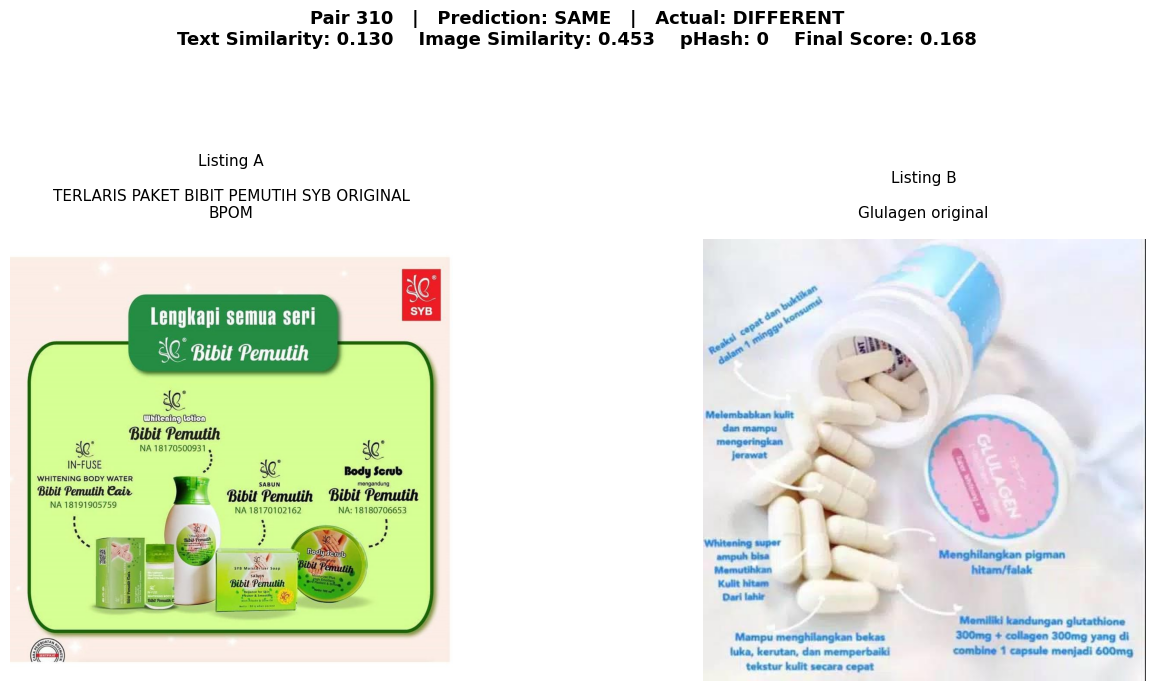

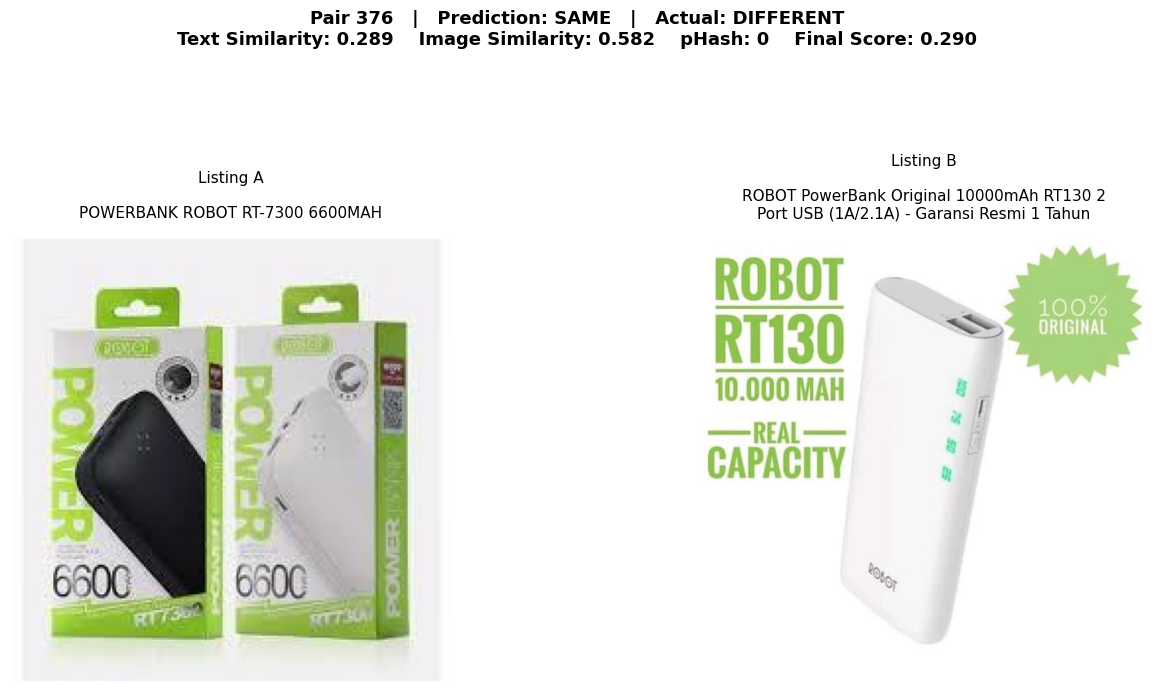

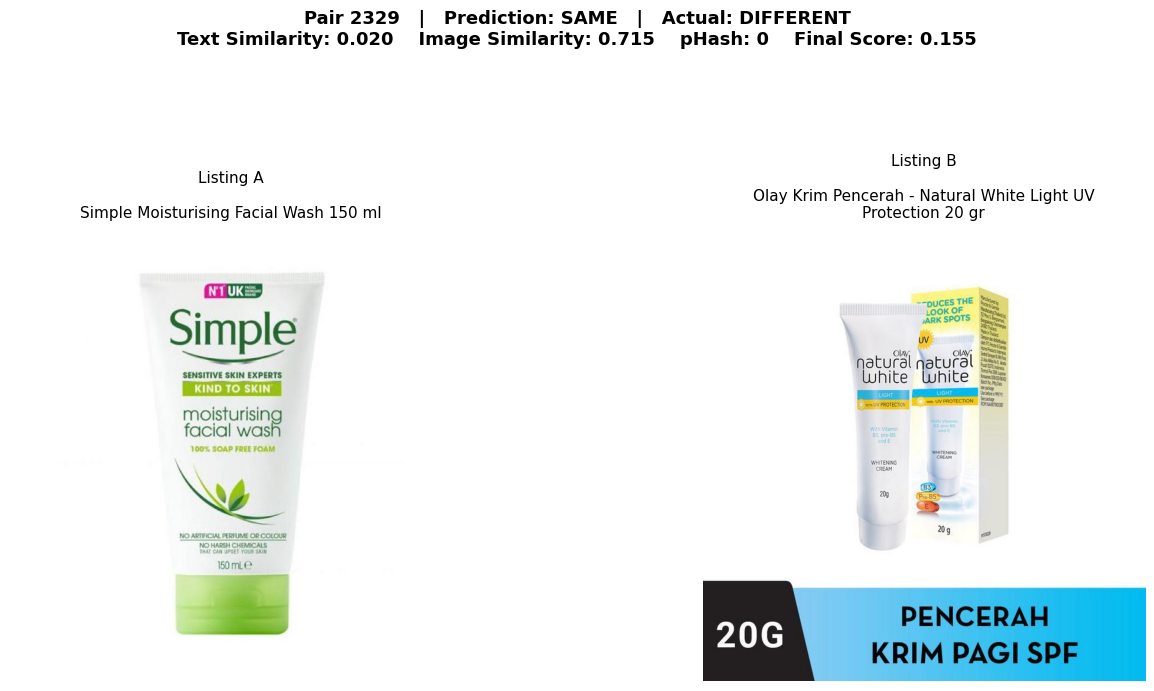

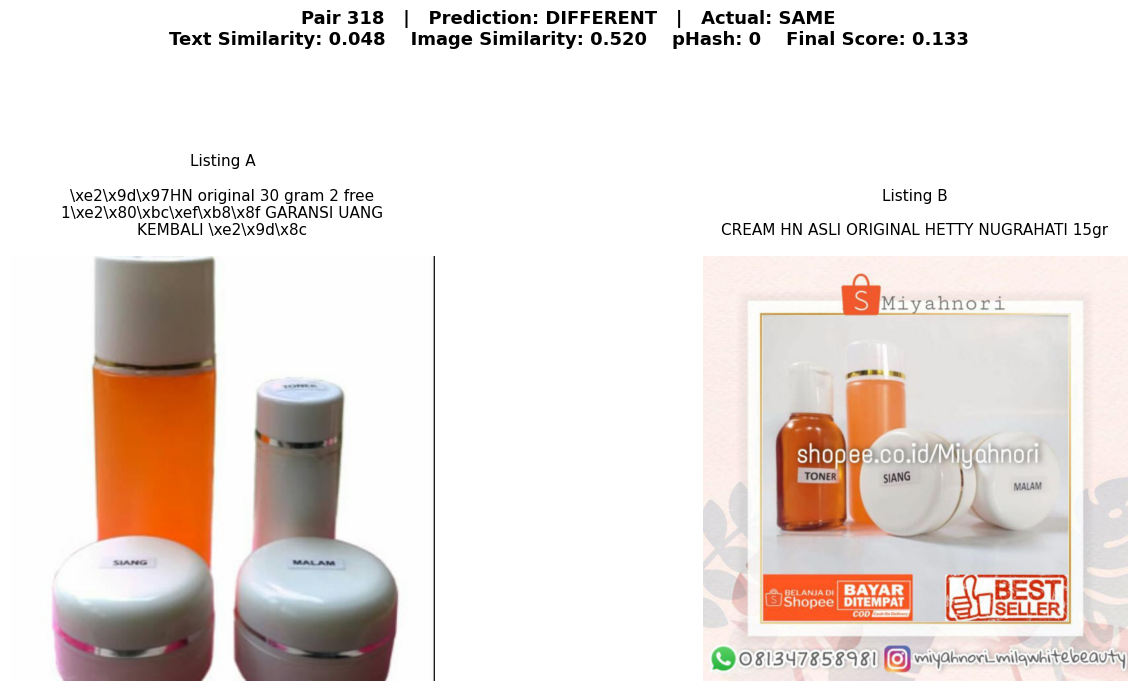

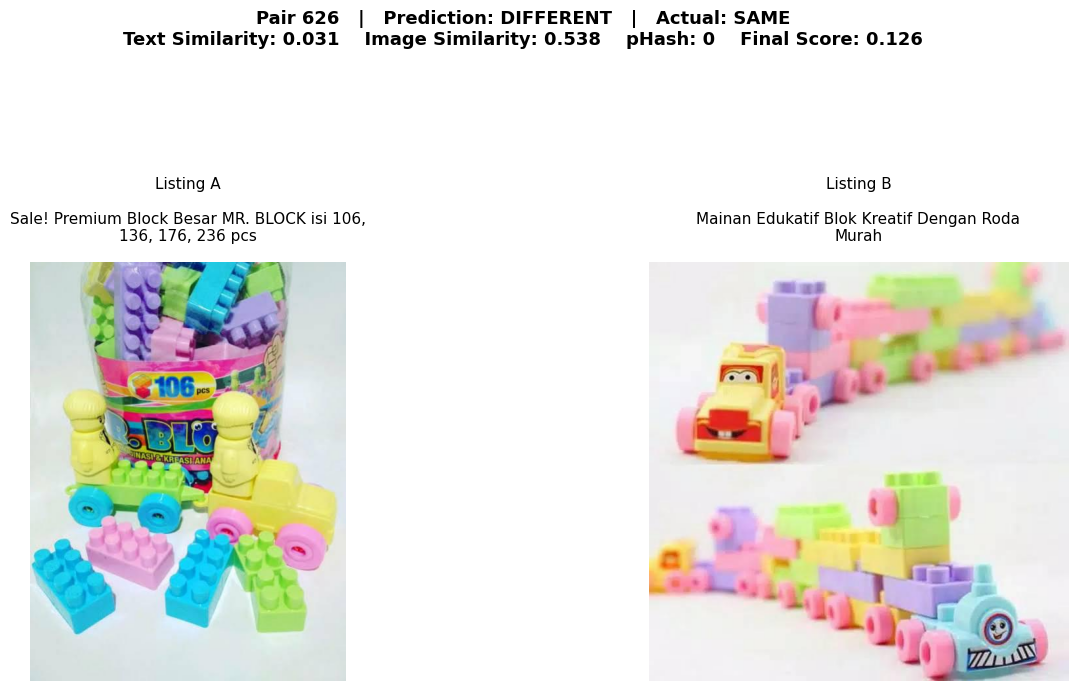

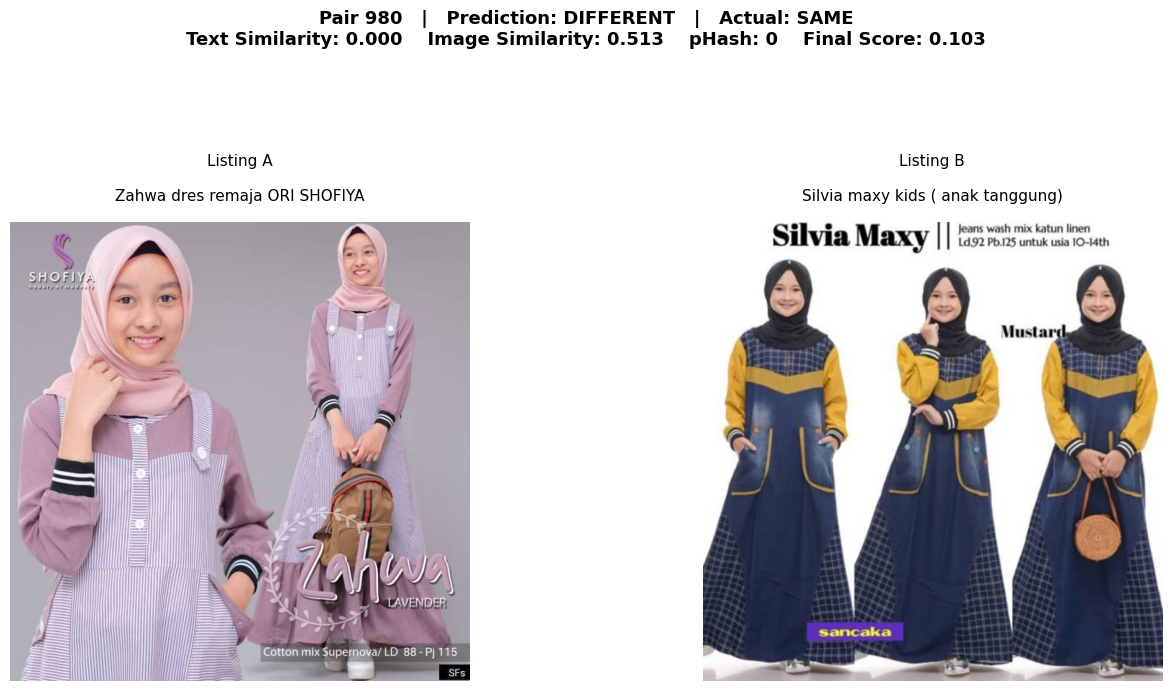

In [40]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import textwrap

IMAGE_DIR = "/kaggle/input/competitions/shopee-product-matching/train_images"

selected_errors = [
    310,   # False positive
    376,   # False positive
    2329,  # False positive
    318,   # False negative
    626,   # False negative
    980    # False negative
]

for pair_index in selected_errors:

    row = errors_df[
        errors_df["pair_index"] == pair_index
    ].iloc[0]

    img1 = Image.open(
        os.path.join(IMAGE_DIR, row["image_1"])
    ).convert("RGB")

    img2 = Image.open(
        os.path.join(IMAGE_DIR, row["image_2"])
    ).convert("RGB")

    # Wrap titles so they don't overlap
    title1 = "\n".join(
        textwrap.wrap(str(row["title_1"]), width=45)
    )

    title2 = "\n".join(
        textwrap.wrap(str(row["title_2"]), width=45)
    )

    prediction_text = (
        "SAME" if row["prediction"] == 1 else "DIFFERENT"
    )

    actual_text = (
        "SAME" if row["actual"] == 1 else "DIFFERENT"
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 7)
    )

    # Image 1
    axes[0].imshow(img1)
    axes[0].axis("off")
    axes[0].set_title(
        "Listing A\n\n" + title1,
        fontsize=11,
        pad=15
    )

    # Image 2
    axes[1].imshow(img2)
    axes[1].axis("off")
    axes[1].set_title(
        "Listing B\n\n" + title2,
        fontsize=11,
        pad=15
    )

    # Metrics at top
    fig.suptitle(
        f"Pair {pair_index}   |   "
        f"Prediction: {prediction_text}   |   "
        f"Actual: {actual_text}\n"
        f"Text Similarity: {row['text_similarity']:.3f}    "
        f"Image Similarity: {row['image_similarity']:.3f}    "
        f"pHash: {row['phash_match']}    "
        f"Final Score: {row['final_score']:.3f}",
        fontsize=13,
        fontweight="bold",
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.84])
    plt.show()